# Analysis of Variance (ANOVA)

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain **why comparing 3+ group means with multiple t-tests fails** (the multiple testing problem).
2. Derive the **sum of squares decomposition** SST = SSB + SSW and construct the **F-statistic**.
3. Carry out a complete **one-way ANOVA** by hand and interpret the ANOVA table.
4. Show that **one-way ANOVA is equivalent to regression with dummy variables** — the key conceptual insight.
5. Implement ANOVA **from scratch** and verify against `scipy.stats.f_oneway`.
6. Check ANOVA **assumptions** (independence, normality, homoscedasticity) and apply **Levene's test**.
7. Perform **Tukey's HSD** post-hoc test to identify which groups differ.
8. Use `statsmodels` to produce a professional ANOVA table via `anova_lm`.
9. Describe the structure of **two-way ANOVA** and interaction effects.

## Prerequisites

- [Module 02](../02_distributions/02_continuous_distributions.ipynb) — F-distribution
- [Module 05](../05_hypothesis_testing/01_hypothesis_framework.ipynb) — Hypothesis testing framework, p-values
- [06_01](01_simple_linear_regression.ipynb) — Simple linear regression (for the ANOVA-as-regression connection)

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. The Problem: Comparing More Than Two Groups

Suppose we run an experiment with **three fertilisers** (A, B, C) and measure crop yield. We want to know: *do the fertilisers produce different average yields?*

The naive approach: run all pairwise t-tests (A vs. B, A vs. C, B vs. C). With $k = 3$ groups that's $\binom{3}{2} = 3$ tests. With $k = 5$ groups it's 10 tests. With $k = 10$ it's 45.

### Why multiple t-tests fail

Each t-test has a Type I error rate of $\alpha$. If we do $m$ independent tests, the probability of **at least one** false positive is:

$$P(\text{at least one false positive}) = 1 - (1 - \alpha)^m$$

| Groups $k$ | Pairwise tests $m$ | Family-wise error rate ($\alpha = 0.05$) |
|------------|--------------------|------------------------------------------|
| 3          | 3                  | 0.143                                    |
| 5          | 10                 | 0.401                                    |
| 10         | 45                 | 0.901                                    |

With 10 groups, there is a **90% chance** of at least one false positive even when all group means are identical. This is the **multiple testing problem** (see Module 05).

**ANOVA solves this** by asking a single question with a single test: "Are *any* of the group means different?" — controlling the Type I error rate at $\alpha$ regardless of the number of groups.

In [3]:
# Demonstrate the multiple testing problem
# All groups have the SAME mean — any rejection is a false positive
# ATTENTION: This is a simulation , written in pure Python, and can be slow for large n_sim or k!
# below is a faster versn
n_sim = 10_00
alpha = 0.05

results = {}
for k in [3, 5, 10]:
    false_pos = 0
    for _ in range(n_sim):
        groups = [rng.normal(0, 1, size=20) for _ in range(k)]
        # Do all pairwise t-tests
        any_sig = False
        for i in range(k):
            for j in range(i + 1, k):
                _, p = stats.ttest_ind(groups[i], groups[j])
                if p < alpha:
                    any_sig = True
                    break
            if any_sig:
                break
        false_pos += any_sig
    results[k] = false_pos / n_sim

print("Family-wise error rate from multiple t-tests (H₀ true for all):")
print(f"{'Groups':>8}  {'Pairs':>6}  {'Theory':>8}  {'Simulated':>10}")
for k, rate in results.items():
    m = k * (k - 1) // 2
    theory = 1 - (1 - alpha) ** m
    print(f"{k:>8}  {m:>6}  {theory:>8.3f}  {rate:>10.3f}")

Family-wise error rate from multiple t-tests (H₀ true for all):
  Groups   Pairs    Theory   Simulated
       3       3     0.143       0.120
       5      10     0.401       0.251
      10      45     0.901       0.637


In [3]:
# faster version using vectorization and scipy's t-test across multiple simulations at once
import numpy as np
from scipy import stats
from itertools import combinations

rng = np.random.default_rng()
n_sim = 10_000
alpha = 0.05
group_sizes = [3, 5, 10]
results = {}

for k in group_sizes:
    # Generate all simulations at once: shape (n_sim, k, 20)
    groups = rng.normal(0, 1, size=(n_sim, k, 20))
    any_sig = np.zeros(n_sim, dtype=bool)
    for i, j in combinations(range(k), 2):
        # Vectorized t-test across all simulations
        _, p = stats.ttest_ind(groups[:, i, :], groups[:, j, :], axis=1)
        any_sig |= p < alpha
    results[k] = np.mean(any_sig)

print("Family-wise error rate from multiple t-tests (H₀ true for all):")
print(f"{'Groups':>8}  {'Pairs':>6}  {'Theory':>8}  {'Simulated':>10}")
for k, rate in results.items():
    m = k * (k - 1) // 2
    theory = 1 - (1 - alpha) ** m
    print(f"{k:>8}  {m:>6}  {theory:>8.3f}  {rate:>10.3f}")

Family-wise error rate from multiple t-tests (H₀ true for all):
  Groups   Pairs    Theory   Simulated
       3       3     0.143       0.125
       5      10     0.401       0.283
      10      45     0.901       0.626


The simulated rates closely match the theoretical family-wise error rates. With 10 groups, the naive pairwise approach has nearly a 90% chance of a false discovery. ANOVA keeps this at exactly $\alpha = 0.05$.

---

## 2. One-Way ANOVA

### 2.1 The Model

We have $k$ groups, with $n_i$ observations in group $i$ (total $n = \sum n_i$). The one-way ANOVA model is:

$$Y_{ij} = \mu + \alpha_i + \varepsilon_{ij}, \quad \varepsilon_{ij} \stackrel{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2)$$

where:
- $Y_{ij}$ is the $j$-th observation in group $i$,
- $\mu$ is the **overall (grand) mean**,
- $\alpha_i$ is the **effect of group $i$** (how much group $i$'s mean deviates from $\mu$), with the constraint $\sum_{i=1}^k n_i \alpha_i = 0$,
- $\varepsilon_{ij}$ is the random error.

The group mean is $\mu_i = \mu + \alpha_i$.

**The null hypothesis** is that all group effects are zero — i.e., all groups share the same mean:

$$H_0: \alpha_1 = \alpha_2 = \cdots = \alpha_k = 0 \quad \Longleftrightarrow \quad \mu_1 = \mu_2 = \cdots = \mu_k$$

$$H_1: \text{at least one } \alpha_i \neq 0$$

### 2.2 Sum of Squares Decomposition

The core idea: **partition the total variability** in the data into two components — variability *between* groups (signal) and variability *within* groups (noise).

Define the following quantities:
- $\bar{Y}_{\cdot\cdot}$ = grand mean (mean of all observations)
- $\bar{Y}_{i\cdot}$ = mean of group $i$

Start with the identity:

$$Y_{ij} - \bar{Y}_{\cdot\cdot} = \underbrace{(\bar{Y}_{i\cdot} - \bar{Y}_{\cdot\cdot})}_{\text{between-group}} + \underbrace{(Y_{ij} - \bar{Y}_{i\cdot})}_{\text{within-group}}$$

Square both sides and sum over all observations:

$$\sum_{i=1}^k \sum_{j=1}^{n_i} (Y_{ij} - \bar{Y}_{\cdot\cdot})^2 = \sum_{i=1}^k \sum_{j=1}^{n_i} \left[(\bar{Y}_{i\cdot} - \bar{Y}_{\cdot\cdot}) + (Y_{ij} - \bar{Y}_{i\cdot})\right]^2$$

Expanding the square on the right:

$$= \sum_{i=1}^k \sum_{j=1}^{n_i} (\bar{Y}_{i\cdot} - \bar{Y}_{\cdot\cdot})^2 + 2\sum_{i=1}^k \sum_{j=1}^{n_i} (\bar{Y}_{i\cdot} - \bar{Y}_{\cdot\cdot})(Y_{ij} - \bar{Y}_{i\cdot}) + \sum_{i=1}^k \sum_{j=1}^{n_i} (Y_{ij} - \bar{Y}_{i\cdot})^2$$

The **cross term vanishes** because for each group $i$:

$$\sum_{j=1}^{n_i} (Y_{ij} - \bar{Y}_{i\cdot}) = 0$$

(the deviations from the group mean sum to zero). Therefore:

$$\boxed{\text{SST} = \text{SSB} + \text{SSW}}$$

where:

| Sum of squares                                                        | Formula        | Measures                    |
|-----------------------------------------------------------------------|----------------|-----------------------------|
| $\text{SST} = \sum_i \sum_j (Y_{ij} - \bar{Y}_{\cdot\cdot})^2$        | Total          | Overall variability         |
| $\text{SSB} = \sum_i n_i (\bar{Y}_{i\cdot} - \bar{Y}_{\cdot\cdot})^2$ | Between groups | How much group means differ |
| $\text{SSW} = \sum_i \sum_j (Y_{ij} - \bar{Y}_{i\cdot})^2$            | Within groups  | Noise within each group     |

### 2.3 Mean Squares and the F-Statistic

The sums of squares depend on the number of observations. To make them comparable, we divide by their **degrees of freedom** to get **mean squares**:

$$\text{MSB} = \frac{\text{SSB}}{k - 1}, \qquad \text{MSW} = \frac{\text{SSW}}{n - k}$$

**Why these degrees of freedom?**
- SSB involves $k$ group means subject to one constraint (the grand mean), so $\text{df}_B = k - 1$.
- SSW involves $n$ observations, each group having lost one df to its group mean, so $\text{df}_W = n - k$.

Under $H_0$ (all group means equal), both MSB and MSW are unbiased estimators of $\sigma^2$, so their ratio should be close to 1. Under $H_1$, MSB is inflated by the group differences, making the ratio large.

The **F-statistic** is:

$$F = \frac{\text{MSB}}{\text{MSW}} \sim F(k-1, \, n-k) \quad \text{under } H_0$$

We reject $H_0$ for large values of $F$ (right tail of the F-distribution).

### The ANOVA Table

| Source         | SS      | df      | MS                  | F               |
|----------------|---------|---------|---------------------|-----------------|
| Between groups | SSB     | $k - 1$ | MSB = SSB / $(k-1)$ | $F$ = MSB / MSW |
| Within groups  | SSW     | $n - k$ | MSW = SSW / $(n-k)$ |                 |
| **Total**      | **SST** | $n - 1$ |                     |                 |

---

## 3. Worked Example: Three Fertilisers

A farmer tests three fertilisers on crop yield (kg per plot). We want to know if the fertiliser type affects yield.

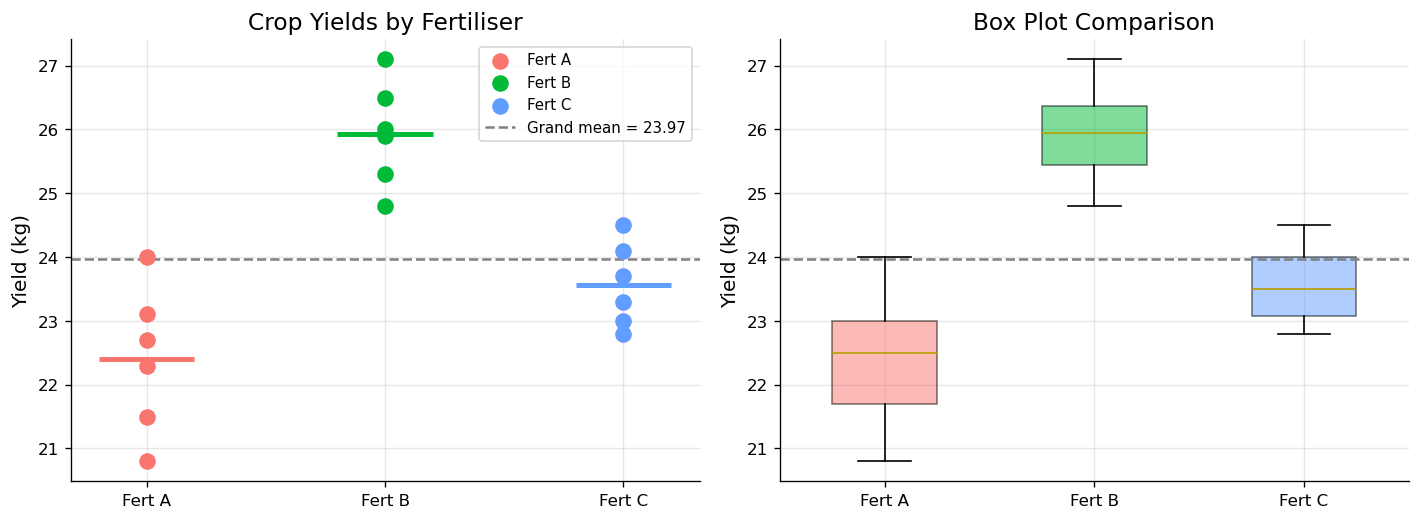

Fert A: mean = 22.40, std = 1.14, n = 6
Fert B: mean = 25.93, std = 0.82, n = 6
Fert C: mean = 23.57, std = 0.66, n = 6
Grand mean: 23.97


In [4]:
# Data: crop yields (kg) for three fertiliser treatments
fert_A = np.array([21.5, 23.1, 22.3, 20.8, 24.0, 22.7])
fert_B = np.array([25.3, 27.1, 26.0, 24.8, 26.5, 25.9])
fert_C = np.array([23.0, 24.5, 22.8, 23.7, 24.1, 23.3])

groups = [fert_A, fert_B, fert_C]
labels = ["Fert A", "Fert B", "Fert C"]
colors = ["#F8766D", "#00BA38", "#619CFF"]

# Visualise the data
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Strip plot
for i, (g, lab, c) in enumerate(zip(groups, labels, colors)):
    axes[0].scatter([i] * len(g), g, color=c, s=80, zorder=3, label=lab)
    axes[0].hlines(g.mean(), i - 0.2, i + 0.2, color=c, linewidth=3)

grand_mean = np.concatenate(groups).mean()
axes[0].axhline(
    grand_mean,
    color="grey",
    linestyle="--",
    linewidth=1.5,
    label=f"Grand mean = {grand_mean:.2f}",
)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Yield (kg)")
axes[0].set_title("Crop Yields by Fertiliser")
axes[0].legend(fontsize=9)

# Box plot
bp = axes[1].boxplot(groups, tick_labels=labels, patch_artist=True, widths=0.5)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)
axes[1].axhline(grand_mean, color="grey", linestyle="--", linewidth=1.5)
axes[1].set_ylabel("Yield (kg)")
axes[1].set_title("Box Plot Comparison")

plt.tight_layout()
plt.show()

for lab, g in zip(labels, groups):
    print(f"{lab}: mean = {g.mean():.2f}, std = {g.std(ddof=1):.2f}, n = {len(g)}")
print(f"Grand mean: {grand_mean:.2f}")

Fertiliser B appears to produce higher yields, while A and C are closer together. But are these differences **statistically significant**, or could they be due to random variation? Let's compute the ANOVA by hand.

In [ ]:
# Step-by-step ANOVA computation
all_data = np.concatenate(groups)
n_total = len(all_data)
k = len(groups)
grand_mean = all_data.mean()

# 1. Sum of Squares Total (SST)
SST = np.sum((all_data - grand_mean) ** 2)
print(f"Step 1: SST = Σ(Yij - Ȳ..)² = {SST:.4f}")

# 2. Sum of Squares Between (SSB)
SSB = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
print(f"Step 2: SSB = Σ ni(Ȳi. - Ȳ..)² = {SSB:.4f}")
for lab, g in zip(labels, groups):
    contrib = len(g) * (g.mean() - grand_mean) ** 2
    print(
        f"         {lab}: {len(g)} × ({g.mean():.2f} - {grand_mean:.2f})² = {contrib:.4f}"
    )

# 3. Sum of Squares Within (SSW)
SSW = sum(np.sum((g - g.mean()) ** 2) for g in groups)
print(f"Step 3: SSW = ΣΣ(Yij - Ȳi.)² = {SSW:.4f}")

# Verify decomposition
print(f"\nCheck: SSB + SSW = {SSB:.4f} + {SSW:.4f} = {SSB + SSW:.4f}")
print(f"        SST     = {SST:.4f}  ✓")

# 4. Degrees of freedom and Mean Squares
df_B = k - 1
df_W = n_total - k
MSB = SSB / df_B
MSW = SSW / df_W
print(f"\nStep 4: MSB = SSB / (k-1) = {SSB:.4f} / {df_B} = {MSB:.4f}")
print(f"        MSW = SSW / (n-k) = {SSW:.4f} / {df_W} = {MSW:.4f}")

# 5. F-statistic and p-value
F_stat = MSB / MSW
p_value = 1 - stats.f.cdf(F_stat, df_B, df_W)
print(f"\nStep 5: F = MSB / MSW = {MSB:.4f} / {MSW:.4f} = {F_stat:.4f}")
print(f"        p-value = P(F({df_B},{df_W}) > {F_stat:.2f}) = {p_value:.6f}")
print(
    f"\nConclusion at α = 0.05: {'REJECT H₀ — fertilisers differ' if p_value < 0.05 else 'Fail to reject H₀'}"
)

Step 1: SST = Σ(Yij - Ȳ..)² = 50.9400
Step 2: SSB = Σ ni(Ȳi. - Ȳ..)² = 38.8933
         Fert A: 6 × (22.40 - 23.97)² = 14.7267
         Fert B: 6 × (25.93 - 23.97)² = 23.2067
         Fert C: 6 × (23.57 - 23.97)² = 0.9600
Step 3: SSW = ΣΣ(Yij - Ȳi.)² = 12.0467

Check: SSB + SSW = 38.8933 + 12.0467 = 50.9400
        SST     = 50.9400  ✓

Step 4: MSB = SSB / (k-1) = 38.8933 / 2 = 19.4467
        MSW = SSW / (n-k) = 12.0467 / 15 = 0.8031

Step 5: F = MSB / MSW = 19.4467 / 0.8031 = 24.2142
        p-value = P(F(2,15) > 24.21) = 0.000020

Conclusion at α = 0.05: REJECT H₀ — fertilisers differ


In [ ]:
# The ANOVA table
anova_table = pd.DataFrame(
    {
        "Source": ["Between (Fertiliser)", "Within (Residual)", "Total"],
        "SS": [SSB, SSW, SST],
        "df": [df_B, df_W, n_total - 1],
        "MS": [MSB, MSW, np.nan],
        "F": [F_stat, np.nan, np.nan],
        "p-value": [p_value, np.nan, np.nan],
    }
).set_index("Source")

print("ANOVA Table")
print("=" * 70)
print(anova_table.to_string(float_format="{:.4f}".format, na_rep=""))

ANOVA Table
                          SS  df      MS       F  p-value
Source                                                   
Between (Fertiliser) 38.8933   2 19.4467 24.2142   0.0000
Within (Residual)    12.0467  15  0.8031                 
Total                50.9400  17                         


The F-statistic is large and the p-value is very small, so we reject $H_0$ at $\alpha = 0.05$. There is strong evidence that the fertilisers produce different average yields.

But **which** fertilisers differ from which? ANOVA tells us that at least one group is different, but not which one. For that we need post-hoc tests (Section 7).

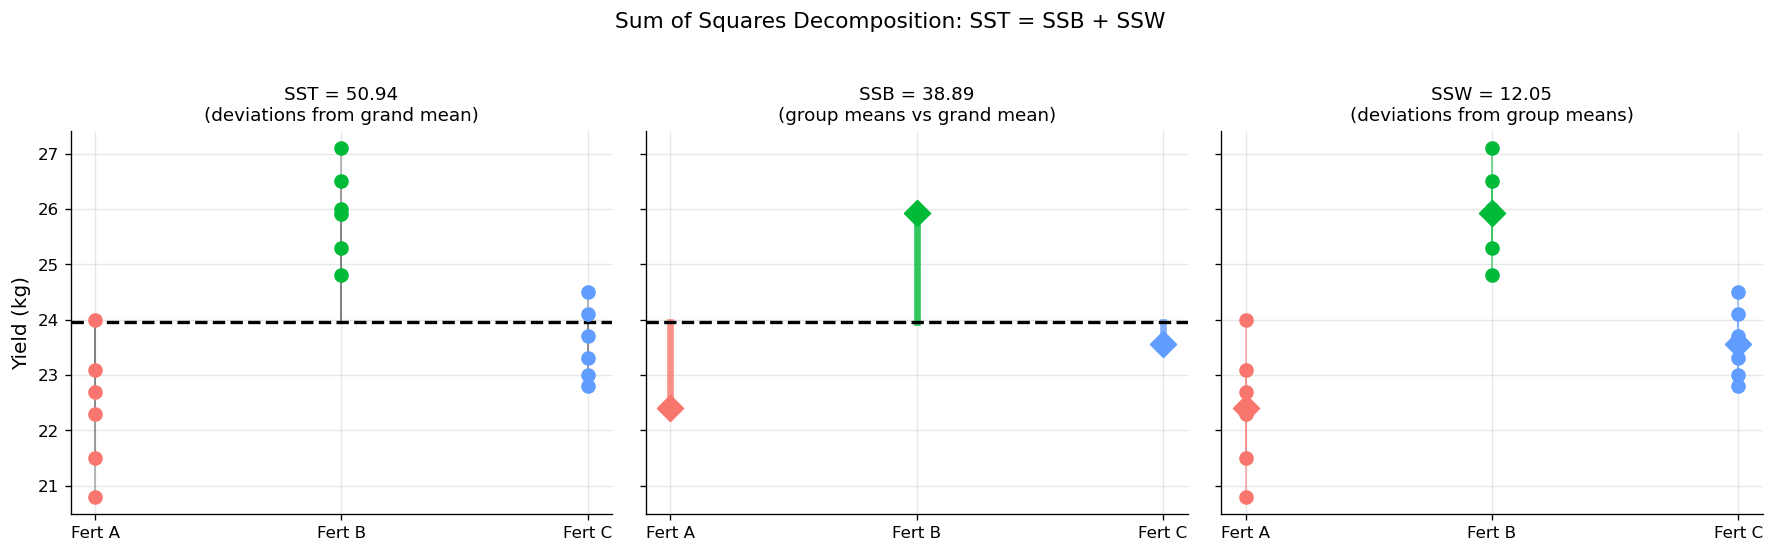

In [8]:
# Visualise the SS decomposition
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

# SST: deviations from grand mean
for i, (g, c) in enumerate(zip(groups, colors)):
    for y in g:
        axes[0].plot([i, i], [grand_mean, y], color="grey", linewidth=1, alpha=0.6)
    axes[0].scatter([i] * len(g), g, color=c, s=60, zorder=3)
axes[0].axhline(grand_mean, color="black", linewidth=2, linestyle="--")
axes[0].set_title(f"SST = {SST:.2f}\n(deviations from grand mean)", fontsize=11)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Yield (kg)")

# SSB: group means vs grand mean
for i, (g, c) in enumerate(zip(groups, colors)):
    axes[1].plot([i, i], [grand_mean, g.mean()], color=c, linewidth=4, alpha=0.8)
    axes[1].scatter([i], [g.mean()], color=c, s=120, zorder=3, marker="D")
axes[1].axhline(grand_mean, color="black", linewidth=2, linestyle="--")
axes[1].set_title(f"SSB = {SSB:.2f}\n(group means vs grand mean)", fontsize=11)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(labels)

# SSW: deviations from group means
for i, (g, c) in enumerate(zip(groups, colors)):
    for y in g:
        axes[2].plot([i, i], [g.mean(), y], color=c, linewidth=1, alpha=0.6)
    axes[2].scatter([i] * len(g), g, color=c, s=60, zorder=3)
    axes[2].scatter([i], [g.mean()], color=c, s=120, zorder=4, marker="D")
axes[2].set_title(f"SSW = {SSW:.2f}\n(deviations from group means)", fontsize=11)
axes[2].set_xticks(range(3))
axes[2].set_xticklabels(labels)

plt.suptitle("Sum of Squares Decomposition: SST = SSB + SSW", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The left panel shows total variation (SST): all deviations from the grand mean. The middle panel shows between-group variation (SSB): how far each group mean is from the grand mean. The right panel shows within-group variation (SSW): the spread of observations around their own group mean. When SSB is large relative to SSW, the groups are well-separated and the F-statistic is large.

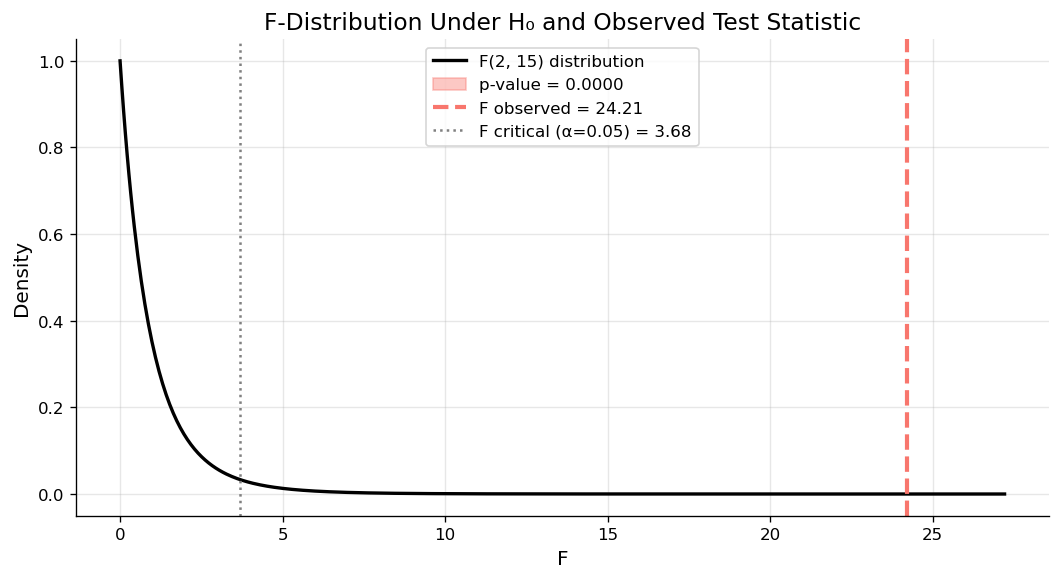

In [ ]:
# Plot the F-distribution and our observed statistic
fig, ax = plt.subplots(figsize=(9, 5))
x = np.linspace(0, max(F_stat + 3, 8), 500)
pdf = stats.f.pdf(x, df_B, df_W)

ax.plot(x, pdf, "k-", linewidth=2, label=f"F({df_B}, {df_W}) distribution")

# Shade the p-value region
mask = x >= F_stat
ax.fill_between(
    x[mask], pdf[mask], color="#F8766D", alpha=0.4, label=f"p-value = {p_value:.4f}"
)

ax.axvline(
    F_stat,
    color="#F8766D",
    linewidth=2.5,
    linestyle="--",
    label=f"F observed = {F_stat:.2f}",
)

# Critical value at α = 0.05
F_crit = stats.f.ppf(0.95, df_B, df_W)
ax.axvline(
    F_crit,
    color="grey",
    linewidth=1.5,
    linestyle=":",
    label=f"F critical (α=0.05) = {F_crit:.2f}",
)

ax.set_xlabel("F")
ax.set_ylabel("Density")
ax.set_title("F-Distribution Under H₀ and Observed Test Statistic")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---

## 4. ANOVA as Regression — The Key Insight

This is the most important conceptual point in this notebook: **one-way ANOVA is exactly equivalent to linear regression with dummy (indicator) variables**.

### The connection

Consider $k = 3$ groups. Define dummy variables:

$$D_{2i} = \begin{cases} 1 & \text{if observation } i \text{ is in group 2} \\ 0 & \text{otherwise} \end{cases}, \qquad D_{3i} = \begin{cases} 1 & \text{if observation } i \text{ is in group 3} \\ 0 & \text{otherwise} \end{cases}$$

Group 1 is the **reference** category (no dummy variable needed — it's captured by the intercept). The regression model is:

$$Y_i = \beta_0 + \beta_1 D_{2i} + \beta_2 D_{3i} + \varepsilon_i$$

The coefficients have direct interpretations:
- $\beta_0 = \bar{Y}_1$ (mean of group 1, the reference)
- $\beta_1 = \bar{Y}_2 - \bar{Y}_1$ (difference between group 2 and group 1)
- $\beta_2 = \bar{Y}_3 - \bar{Y}_1$ (difference between group 3 and group 1)

Testing $H_0: \beta_1 = \beta_2 = 0$ (all groups have the same mean) is the **same test** as ANOVA. The regression F-test equals the ANOVA F-statistic. Let's verify.

In [ ]:
# Build the regression with dummy variables
# Stack all data with group indicators
y = np.concatenate(groups)
group_labels = np.concatenate([[i] * len(g) for i, g in enumerate(groups)])

# Dummy variables (group 0 = reference)
D2 = (group_labels == 1).astype(float)  # group B
D3 = (group_labels == 2).astype(float)  # group C
X = np.column_stack([np.ones(len(y)), D2, D3])

print("Design matrix X (first 3 rows per group):")
print(f"{'Obs':>4}  {'Intercept':>10}  {'D_B':>6}  {'D_C':>6}  {'Y':>8}  {'Group':>6}")
for idx in [0, 1, 2, 6, 7, 8, 12, 13, 14]:
    g_name = labels[int(group_labels[idx])]
    print(
        f"{idx:>4}  {X[idx, 0]:>10.0f}  {X[idx, 1]:>6.0f}  {X[idx, 2]:>6.0f}  {y[idx]:>8.1f}  {g_name:>6}"
    )

# OLS fit: β = (X'X)⁻¹X'y
beta = np.linalg.lstsq(X, y, rcond=None)[0]
print(f"\nOLS coefficients:")
print(
    f"  β₀ (intercept = mean of A) = {beta[0]:.4f}  (actual mean A = {fert_A.mean():.4f})"
)
print(
    f"  β₁ (B - A)                 = {beta[1]:.4f}  (actual diff   = {fert_B.mean() - fert_A.mean():.4f})"
)
print(
    f"  β₂ (C - A)                 = {beta[2]:.4f}  (actual diff   = {fert_C.mean() - fert_A.mean():.4f})"
)

# Regression F-test
y_hat = X @ beta
SS_reg = np.sum((y_hat - y.mean()) ** 2)
SS_res = np.sum((y - y_hat) ** 2)
df_reg = X.shape[1] - 1  # k - 1
df_res = len(y) - X.shape[1]  # n - k
F_reg = (SS_reg / df_reg) / (SS_res / df_res)
p_reg = 1 - stats.f.cdf(F_reg, df_reg, df_res)

print(f"\nRegression F-test:  F = {F_reg:.4f}, p = {p_reg:.6f}")
print(f"ANOVA F-test:       F = {F_stat:.4f}, p = {p_value:.6f}")
print(
    f"\nThey are identical!  SS_regression = SSB = {SS_reg:.4f},  SS_residual = SSW = {SS_res:.4f}"
)

Design matrix X (first 3 rows per group):
 Obs   Intercept     D_B     D_C         Y   Group
   0           1       0       0      21.5  Fert A
   1           1       0       0      23.1  Fert A
   2           1       0       0      22.3  Fert A
   6           1       1       0      25.3  Fert B
   7           1       1       0      27.1  Fert B
   8           1       1       0      26.0  Fert B
  12           1       0       1      23.0  Fert C
  13           1       0       1      24.5  Fert C
  14           1       0       1      22.8  Fert C

OLS coefficients:
  β₀ (intercept = mean of A) = 22.4000  (actual mean A = 22.4000)
  β₁ (B - A)                 = 3.5333  (actual diff   = 3.5333)
  β₂ (C - A)                 = 1.1667  (actual diff   = 1.1667)

Regression F-test:  F = 24.2142, p = 0.000020
ANOVA F-test:       F = 24.2142, p = 0.000020

They are identical!  SS_regression = SSB = 38.8933,  SS_residual = SSW = 12.0467


This equivalence is not a coincidence — it is exact. ANOVA *is* regression with categorical predictors. The ANOVA F-test is the overall regression F-test. Understanding this connection is essential because:

1. It shows that **ANOVA and regression are the same framework** (the general linear model).
2. It lets us extend ANOVA naturally to include covariates (ANCOVA) or multiple factors (multi-way ANOVA).
3. It makes clear that the "effect" of a group is a regression coefficient — with standard errors, confidence intervals, and all the tools of regression.
4. It explains why `statsmodels` performs ANOVA via `anova_lm` — by fitting a linear model and decomposing its sums of squares.

---

## 5. From-Scratch Implementation

Following the course pedagogy, we implement one-way ANOVA from scratch and compare with `scipy.stats.f_oneway`.

In [ ]:
def one_way_anova(groups):
    """One-way ANOVA from scratch.

    Parameters
    ----------
    groups : list of array-like
        Each element is an array of observations for one group.

    Returns
    -------
    dict with keys: SSB, SSW, SST, df_between, df_within, MSB, MSW,
                    F_statistic, p_value, grand_mean, group_means, group_ns
    """
    groups = [np.asarray(g, dtype=float) for g in groups]
    k = len(groups)
    ns = [len(g) for g in groups]
    n_total = sum(ns)
    all_data = np.concatenate(groups)

    # Grand mean and group means
    grand_mean = all_data.mean()
    group_means = [g.mean() for g in groups]

    # Sum of squares
    SSB = sum(n * (m - grand_mean) ** 2 for n, m in zip(ns, group_means))
    SSW = sum(np.sum((g - m) ** 2) for g, m in zip(groups, group_means))
    SST = np.sum((all_data - grand_mean) ** 2)

    # Degrees of freedom
    df_between = k - 1
    df_within = n_total - k

    # Mean squares
    MSB = SSB / df_between
    MSW = SSW / df_within

    # F-statistic and p-value
    F_statistic = MSB / MSW
    p_value = 1 - stats.f.cdf(F_statistic, df_between, df_within)

    return {
        "SSB": SSB,
        "SSW": SSW,
        "SST": SST,
        "df_between": df_between,
        "df_within": df_within,
        "MSB": MSB,
        "MSW": MSW,
        "F_statistic": F_statistic,
        "p_value": p_value,
        "grand_mean": grand_mean,
        "group_means": group_means,
        "group_ns": ns,
    }


# Test on our fertiliser data
result = one_way_anova(groups)

print("From-scratch ANOVA results:")
print(
    f"  SSB = {result['SSB']:.4f}, SSW = {result['SSW']:.4f}, SST = {result['SST']:.4f}"
)
print(f"  MSB = {result['MSB']:.4f}, MSW = {result['MSW']:.4f}")
print(f"  F   = {result['F_statistic']:.4f}")
print(f"  p   = {result['p_value']:.6f}")

From-scratch ANOVA results:
  SSB = 38.8933, SSW = 12.0467, SST = 50.9400
  MSB = 19.4467, MSW = 0.8031
  F   = 24.2142
  p   = 0.000020


In [ ]:
# Compare with scipy.stats.f_oneway
F_scipy, p_scipy = stats.f_oneway(*groups)

print("Comparison: from scratch vs. scipy.stats.f_oneway")
print(
    f"  F-statistic:  {result['F_statistic']:.6f}  vs  {F_scipy:.6f}  "
    f"(match: {np.isclose(result['F_statistic'], F_scipy)})"
)
print(
    f"  p-value:      {result['p_value']:.6f}  vs  {p_scipy:.6f}  "
    f"(match: {np.isclose(result['p_value'], p_scipy)})"
)

Comparison: from scratch vs. scipy.stats.f_oneway
  F-statistic:  24.214167  vs  24.214167  (match: True)
  p-value:      0.000020  vs  0.000020  (match: True)


Our from-scratch implementation matches SciPy exactly. The function computes the full SS decomposition, mean squares, F-statistic, and p-value — everything that goes into the ANOVA table.

---

## 6. Assumptions

ANOVA relies on three assumptions:

### 6.1 Independence

Observations must be independent — both within and between groups. This is a **study design** issue, not something we can test from the data alone. Randomisation and proper experimental design ensure independence.

### 6.2 Normality

Within each group, the data should be approximately normally distributed: $Y_{ij} \mid \text{group } i \sim \mathcal{N}(\mu_i, \sigma^2)$.

In practice, ANOVA is **robust** to moderate departures from normality, especially with balanced designs and moderate-to-large sample sizes (thanks to the CLT). Check with:
- Normal Q-Q plots for each group
- Shapiro-Wilk test per group

### 6.3 Homoscedasticity (Equal Variances)

All groups must have the **same variance** $\sigma^2$. This is the most important assumption — violations inflate the Type I error rate.

**Levene's test** checks this formally:
- $H_0$: all groups have equal variance
- $H_1$: at least one group has a different variance

Levene's test works by performing ANOVA on the **absolute deviations** from each group's median (or mean). If these deviations differ across groups, the variances differ.

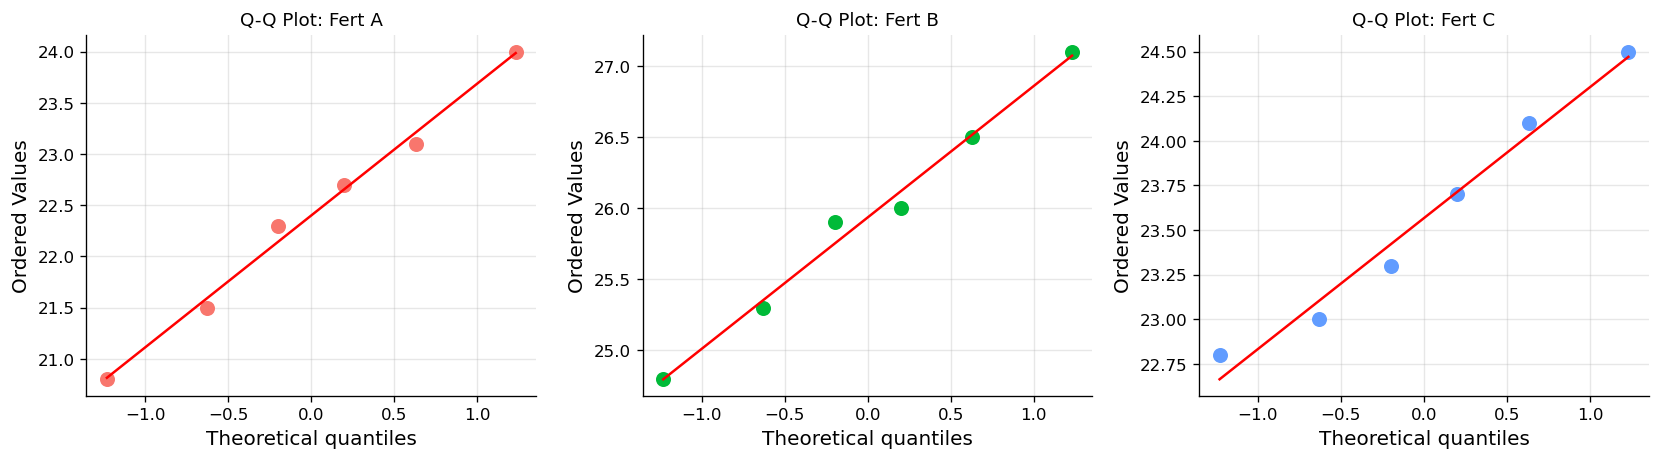

Shapiro-Wilk normality test per group:
  Fert A: W = 0.9910, p = 0.9915 → normal (fail to reject)
  Fert B: W = 0.9868, p = 0.9800 → normal (fail to reject)
  Fert C: W = 0.9591, p = 0.8131 → normal (fail to reject)

Levene's test for equal variances:
  W = 0.7444, p = 0.4918 → equal variances (fail to reject)

Group standard deviations: Fert A: 1.14  Fert B: 0.82  Fert C: 0.66  


In [ ]:
# Check assumptions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Q-Q plots for normality
for i, (g, lab, c) in enumerate(zip(groups, labels, colors)):
    stats.probplot(g, plot=axes[i])
    axes[i].set_title(f"Q-Q Plot: {lab}", fontsize=11)
    axes[i].get_lines()[0].set_color(c)
    axes[i].get_lines()[0].set_markersize(8)

plt.tight_layout()
plt.show()

# Shapiro-Wilk test for normality per group
print("Shapiro-Wilk normality test per group:")
for lab, g in zip(labels, groups):
    stat_sw, p_sw = stats.shapiro(g)
    print(
        f"  {lab}: W = {stat_sw:.4f}, p = {p_sw:.4f} → "
        f"{'normal (fail to reject)' if p_sw > 0.05 else 'NOT normal (reject)'}"
    )

# Levene's test for equal variances
stat_lev, p_lev = stats.levene(*groups)
print(f"\nLevene's test for equal variances:")
print(
    f"  W = {stat_lev:.4f}, p = {p_lev:.4f} → "
    f"{'equal variances (fail to reject)' if p_lev > 0.05 else 'UNEQUAL variances (reject)'}"
)

print(f"\nGroup standard deviations: ", end="")
for lab, g in zip(labels, groups):
    print(f"{lab}: {g.std(ddof=1):.2f}  ", end="")
print()

The Q-Q plots look approximately linear, the Shapiro-Wilk tests do not reject normality, and Levene's test does not reject equal variances. All assumptions are satisfied for our data.

**When assumptions are violated:**
- **Unequal variances:** Use **Welch's ANOVA** (`scipy.stats.alexandergovern` or the Welch correction), which does not assume equal variances.
- **Non-normality:** Use the **Kruskal-Wallis test** (`scipy.stats.kruskal`), a non-parametric alternative that compares ranks instead of means.

---

## 7. Post-Hoc Tests: Which Groups Differ?

ANOVA only tells us *whether* the groups differ, not *which* ones. If we reject $H_0$, we need a **post-hoc** (after the fact) procedure to identify the specific pairwise differences while controlling the family-wise error rate.

### Tukey's Honest Significant Difference (HSD)

Tukey's HSD compares all pairs of group means. For groups $i$ and $j$ with equal sample sizes $n$:

$$q = \frac{|\bar{Y}_{i\cdot} - \bar{Y}_{j\cdot}|}{\sqrt{\text{MSW} / n}}$$

This is compared to the **Studentised range distribution** $q_{\alpha, k, n-k}$. A pair is significantly different if $q > q_{\alpha, k, n-k}$.

Equivalently, the **HSD threshold** is:

$$\text{HSD} = q_{\alpha, k, n-k} \cdot \sqrt{\text{MSW} / n}$$

Any pair whose mean difference exceeds HSD is declared significantly different.

In [15]:
from scipy.stats import studentized_range

# Tukey's HSD (equal sample sizes)
n_per_group = len(fert_A)  # all groups have n = 6
q_crit = studentized_range.ppf(0.95, k, df_W)
HSD = q_crit * np.sqrt(MSW / n_per_group)

print(f"Tukey's HSD at α = 0.05:")
print(f"  q critical (k={k}, df={df_W}) = {q_crit:.4f}")
print(f"  MSW = {MSW:.4f}, n per group = {n_per_group}")
print(f"  HSD = {q_crit:.4f} × √({MSW:.4f}/{n_per_group}) = {HSD:.4f}")
print(f"\nPairwise comparisons (reject if |diff| > {HSD:.4f}):")
print(f"{'Pair':<15} {'Diff':>8} {'|Diff| > HSD?':>15} {'Conclusion':>20}")
print("-" * 60)

group_means = [g.mean() for g in groups]
for i in range(k):
    for j in range(i + 1, k):
        diff = group_means[j] - group_means[i]
        sig = abs(diff) > HSD
        sig_str = "Yes" if sig else "No"
        conclusion = "*** Significant" if sig else "Not significant"
        print(
            f"{labels[i]} vs {labels[j]:<8} {diff:+8.4f} {sig_str:>15} {conclusion:>20}"
        )

Tukey's HSD at α = 0.05:
  q critical (k=3, df=15) = 3.6734
  MSW = 0.8031, n per group = 6
  HSD = 3.6734 × √(0.8031/6) = 1.3439

Pairwise comparisons (reject if |diff| > 1.3439):
Pair                Diff   |Diff| > HSD?           Conclusion
------------------------------------------------------------
Fert A vs Fert B    +3.5333             Yes      *** Significant
Fert A vs Fert C    +1.1667              No      Not significant
Fert B vs Fert C    -2.3667             Yes      *** Significant


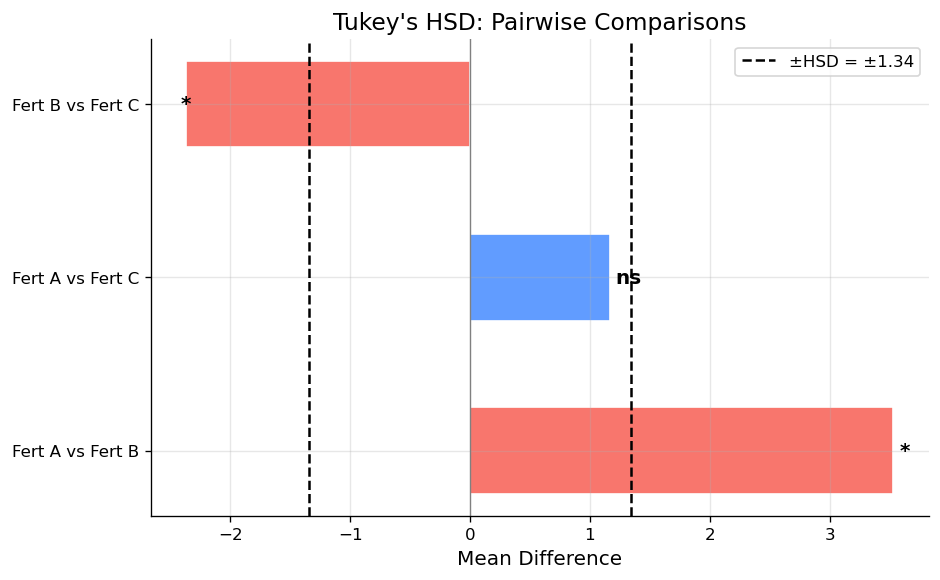

In [ ]:
# Visualise pairwise differences with HSD threshold
fig, ax = plt.subplots(figsize=(8, 5))

pairs = []
diffs = []
pair_labels = []
for i in range(k):
    for j in range(i + 1, k):
        diff = group_means[j] - group_means[i]
        pairs.append((i, j))
        diffs.append(diff)
        pair_labels.append(f"{labels[i]} vs {labels[j]}")

y_pos = range(len(diffs))
bar_colors = ["#F8766D" if abs(d) > HSD else "#619CFF" for d in diffs]
ax.barh(y_pos, diffs, color=bar_colors, edgecolor="white", height=0.5)
ax.axvline(
    -HSD, color="black", linewidth=1.5, linestyle="--", label=f"±HSD = ±{HSD:.2f}"
)
ax.axvline(HSD, color="black", linewidth=1.5, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(pair_labels)
ax.set_xlabel("Mean Difference")
ax.set_title("Tukey's HSD: Pairwise Comparisons")
ax.legend(fontsize=10)

# Annotate significance
for i, (d, lab) in enumerate(zip(diffs, pair_labels)):
    sig_text = "*" if abs(d) > HSD else "ns"
    ax.text(
        d + 0.05 * np.sign(d), i, sig_text, va="center", fontsize=12, fontweight="bold"
    )

plt.tight_layout()
plt.show()

Tukey's HSD identifies which pairwise differences exceed the critical threshold. Bars extending beyond the dashed lines are significantly different. This tells us *specifically* which fertilisers have different effects, while properly controlling the family-wise error rate.

---

## 8. Professional Tool: `statsmodels` ANOVA

In practice, we use `statsmodels` to produce ANOVA tables. The function `anova_lm` performs ANOVA by fitting a linear model (reinforcing the ANOVA-as-regression connection) and decomposing the sums of squares.

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# Build a DataFrame for statsmodels formula API
df = pd.DataFrame(
    {
        "yield_kg": np.concatenate(groups),
        "fertiliser": np.repeat(["A", "B", "C"], [len(g) for g in groups]),
    }
)

print(df.head(8).to_string(index=False))
print("...")

 yield_kg fertiliser
     21.5          A
     23.1          A
     22.3          A
     20.8          A
     24.0          A
     22.7          A
     25.3          B
     27.1          B
...


In [18]:
# Fit the linear model and compute the ANOVA table
model = ols("yield_kg ~ C(fertiliser)", data=df).fit()

print("Statsmodels ANOVA Table")
print("=" * 65)
table = anova_lm(model)
print(table)

print(f"\nVerification:")
print(f"  F (statsmodels) = {table['F'].iloc[0]:.4f}")
print(f"  F (from scratch) = {result['F_statistic']:.4f}")
print(f"  Match: {np.isclose(table['F'].iloc[0], result['F_statistic'])}")

Statsmodels ANOVA Table
                 df     sum_sq    mean_sq          F   PR(>F)
C(fertiliser)   2.0  38.893333  19.446667  24.214167  0.00002
Residual       15.0  12.046667   0.803111        NaN      NaN

Verification:
  F (statsmodels) = 24.2142
  F (from scratch) = 24.2142
  Match: True


In [19]:
# The regression summary gives us the dummy-variable coefficients
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               yield_kg   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     24.21
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           2.01e-05
Time:                        17:34:27   Log-Likelihood:                -21.927
No. Observations:                  18   AIC:                             49.85
Df Residuals:                      15   BIC:                             52.52
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             22.4000      0

c:\Users\Alexander_Timmer\Miniconda3\envs\amstats\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


Notice the regression summary: the intercept is the mean of the reference group (A), and the coefficients for `C(fertiliser)[T.B]` and `C(fertiliser)[T.C]` are the differences from A. This is exactly the dummy-variable regression from Section 4.

The ANOVA table from `anova_lm` matches our from-scratch computation exactly. In practice, this is what you would use — but now you know exactly what it is doing under the hood.

---

## 9. Two-Way ANOVA (Brief Overview)

When the response depends on **two factors**, we use **two-way ANOVA**. For example, crop yield might depend on both *fertiliser* (A, B, C) and *soil type* (clay, loam, sand).

### The model

$$Y_{ijk} = \mu + \alpha_i + \beta_j + (\alpha\beta)_{ij} + \varepsilon_{ijk}$$

where:
- $\alpha_i$ = effect of factor 1 (fertiliser), level $i$
- $\beta_j$ = effect of factor 2 (soil type), level $j$
- $(\alpha\beta)_{ij}$ = **interaction effect** — the combined effect beyond the individual effects

### Three null hypotheses

Two-way ANOVA tests three things simultaneously:

| Hypothesis                                        | Question                                 |
|---------------------------------------------------|------------------------------------------|
| $H_0^A: \alpha_1 = \cdots = \alpha_a = 0$         | Is there a main effect of factor A?      |
| $H_0^B: \beta_1 = \cdots = \beta_b = 0$           | Is there a main effect of factor B?      |
| $H_0^{AB}: (\alpha\beta)_{ij} = 0 \; \forall i,j$ | Is there an interaction between A and B? |

### Interaction effects

An **interaction** means the effect of one factor depends on the level of the other. For example, fertiliser B might work well in loam soil but poorly in clay. Without the interaction term, we would miss this.

In [ ]:
# Two-way ANOVA example: fertiliser × soil type
# Simulated data with an interaction effect
np.random.seed(42)
n_rep = 5  # observations per cell

fertilisers = ["A", "B", "C"]
soils = ["Clay", "Loam", "Sand"]

# True effects (with interaction: B works especially well in Loam)
mu = 22.0
alpha_eff = {"A": 0, "B": 3.0, "C": 1.0}  # fertiliser effects
beta_eff = {"Clay": -1.0, "Loam": 1.5, "Sand": -0.5}  # soil effects
interaction = {("B", "Loam"): 2.5, ("B", "Sand"): -2.0}  # non-zero interactions

rows = []
for f in fertilisers:
    for s in soils:
        cell_mean = mu + alpha_eff[f] + beta_eff[s] + interaction.get((f, s), 0)
        for _ in range(n_rep):
            rows.append(
                {"fertiliser": f, "soil": s, "yield_kg": cell_mean + rng.normal(0, 1.2)}
            )

df2 = pd.DataFrame(rows)

# Two-way ANOVA with interaction
model2 = ols("yield_kg ~ C(fertiliser) * C(soil)", data=df2).fit()
table2 = anova_lm(model2, typ=2)

print("Two-Way ANOVA Table")
print("=" * 70)
print(table2)

print("\nInterpretation:")
for source in table2.index[:-1]:  # skip Residual
    p = table2.loc[source, "PR(>F)"]
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  {source}: p = {p:.4f} → {sig}")

Two-Way ANOVA Table
                          sum_sq    df          F        PR(>F)
C(fertiliser)          79.398032   2.0  42.001158  3.872859e-10
C(soil)                91.224084   2.0  48.257080  6.497163e-11
C(fertiliser):C(soil)  42.570581   4.0  11.259811  4.994289e-06
Residual               34.026790  36.0        NaN           NaN

Interpretation:
  C(fertiliser): p = 0.0000 → significant
  C(soil): p = 0.0000 → significant
  C(fertiliser):C(soil): p = 0.0000 → significant


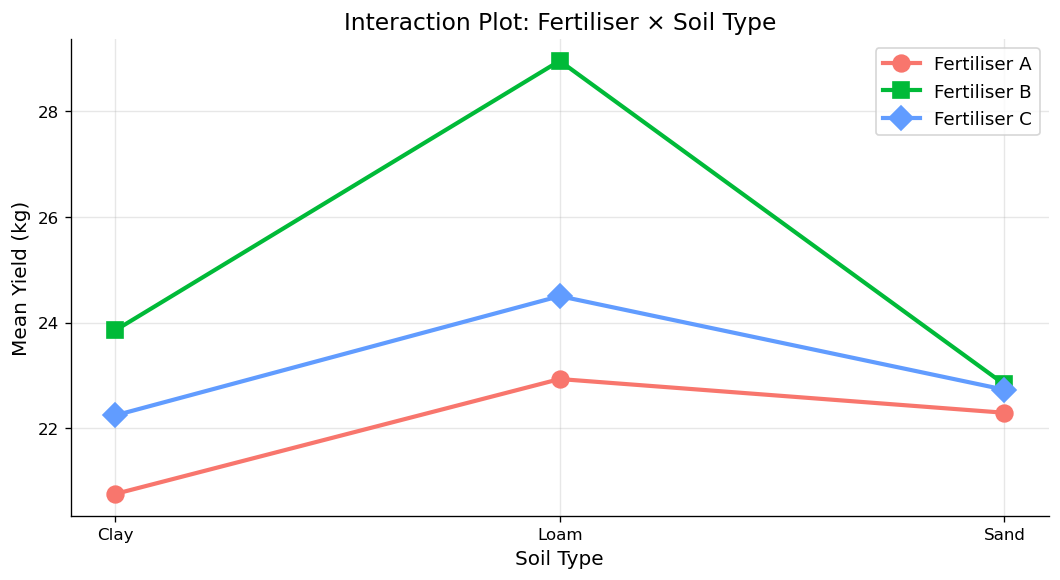

In [ ]:
# Interaction plot: the key diagnostic for two-way ANOVA
fig, ax = plt.subplots(figsize=(9, 5))

soil_positions = {"Clay": 0, "Loam": 1, "Sand": 2}
fert_colors = {"A": "#F8766D", "B": "#00BA38", "C": "#619CFF"}
fert_markers = {"A": "o", "B": "s", "C": "D"}

for f in fertilisers:
    means = [
        df2[(df2["fertiliser"] == f) & (df2["soil"] == s)]["yield_kg"].mean()
        for s in soils
    ]
    ax.plot(
        list(soil_positions.values()),
        means,
        color=fert_colors[f],
        marker=fert_markers[f],
        markersize=10,
        linewidth=2.5,
        label=f"Fertiliser {f}",
    )

ax.set_xticks(list(soil_positions.values()))
ax.set_xticklabels(soils)
ax.set_xlabel("Soil Type")
ax.set_ylabel("Mean Yield (kg)")
ax.set_title("Interaction Plot: Fertiliser × Soil Type")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In the interaction plot, **parallel lines** would indicate no interaction (the effect of fertiliser is the same regardless of soil). **Non-parallel lines** indicate an interaction — the effect of fertiliser depends on the soil type. Here, fertiliser B performs dramatically better in loam than in sand, while A and C are relatively consistent across soils. This is captured by the significant interaction term in the ANOVA table.

---

## Exercises

**Exercise 4.1 (Manual ANOVA).** Three teaching methods are tested on student exam scores:
- Method A: 78, 82, 85, 79, 81
- Method B: 88, 91, 87, 90, 85
- Method C: 80, 83, 79, 82, 84

Compute SST, SSB, SSW, the F-statistic, and the p-value by hand (with a calculator or basic Python). Construct the full ANOVA table. At $\alpha = 0.05$, do the teaching methods differ?

**Exercise 4.2 (Dummy regression).** Using the teaching methods data from Exercise 4.1, set up the design matrix $X$ with dummy variables (Method A as reference). Fit the OLS regression using `np.linalg.lstsq`. Verify that (a) the intercept equals the mean of Method A, (b) the coefficients equal the differences from A, and (c) the regression F-test matches the ANOVA F-statistic.

**Exercise 4.3 (Assumption checking).** Generate four groups of size 30 from:
- Group 1: $\mathcal{N}(10, 2^2)$
- Group 2: $\mathcal{N}(10, 2^2)$
- Group 3: $\mathcal{N}(10, 8^2)$  (much larger variance!)
- Group 4: $\mathcal{N}(10, 2^2)$

All groups have the same mean, so $H_0$ is true. (a) Run Levene's test — does it detect the unequal variance? (b) Run ANOVA 10,000 times and measure the actual false rejection rate at $\alpha = 0.05$. Is it close to 5%? (c) Repeat with Welch's ANOVA. How does the false rejection rate compare?

**Exercise 4.4 (Post-hoc).** Four diets are compared for weight loss (kg lost in 8 weeks):
- Diet 1: 3.2, 4.1, 2.8, 3.5, 4.0, 3.7
- Diet 2: 5.1, 4.8, 5.5, 5.0, 4.6, 5.3
- Diet 3: 3.0, 3.3, 2.5, 3.8, 2.9, 3.1
- Diet 4: 4.5, 4.2, 4.8, 4.0, 4.7, 4.3

Perform one-way ANOVA. If significant, apply Tukey's HSD. Which diets are significantly different from which? Present a clear summary of all pairwise comparisons.

**Exercise 4.5 (Two-way ANOVA).** A psychologist studies the effect of *study method* (flashcards, practice tests, reading) and *time of day* (morning, evening) on recall score. Generate a balanced dataset ($n = 8$ per cell) where:
- Practice tests improve recall by 5 points over reading.
- Flashcards improve recall by 2 points over reading.
- Morning is 1.5 points better than evening.
- There is an interaction: practice tests are 3 points *extra* effective in the morning.

Fit the two-way ANOVA with interaction using `statsmodels`. (a) Which effects are significant? (b) Produce an interaction plot and explain what the non-parallel lines mean substantively.

---

## Key Takeaways

1. **Multiple t-tests inflate the false positive rate.** ANOVA provides a single test for whether any group means differ.
2. **The SS decomposition** SST = SSB + SSW partitions total variation into between-group (signal) and within-group (noise) components.
3. **The F-statistic** $F = \text{MSB}/\text{MSW}$ compares the two sources of variation. Under $H_0$, $F \sim F(k-1, n-k)$.
4. **ANOVA is regression with dummy variables.** This is the key conceptual insight — they are the same framework (the general linear model).
5. **Check assumptions:** independence, normality (robust), and especially **equal variances** (use Levene's test). Use Welch's ANOVA or Kruskal-Wallis when assumptions fail.
6. **ANOVA only says *whether* groups differ,** not *which*. Use **Tukey's HSD** (or other post-hoc tests) to identify specific differences.
7. **Two-way ANOVA** extends to two factors and can detect **interaction effects** — when the effect of one factor depends on the level of another.

**Next:** [05_model_selection.ipynb](05_model_selection.ipynb) — Model selection criteria: how to choose between competing models using AIC, BIC, and cross-validation.

In [22]:
cfg.save_gifs(clean=True)

  No new GIFs to save.
